✅ Best Params: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



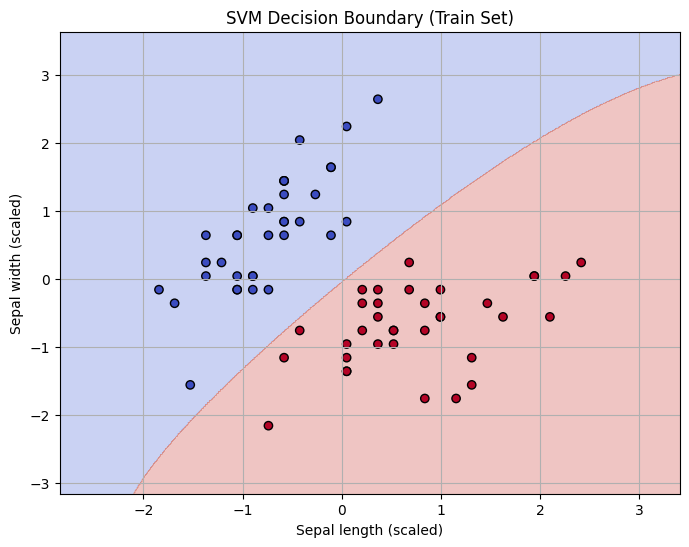

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
# Load Iris dataset (select 2 classes & 2 features for visualization)
iris = load_iris()
X = iris.data[:, :2]  # Only first two features (sepal length & width)
y = iris.target
mask = y < 2  # Select class 0 and 1 only
X = X[mask]
y = y[mask]
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# SVC with Grid Search
param_grid = {
   'C': [0.1, 1, 10],
   'kernel': ['linear', 'rbf', 'poly'],
   'gamma': ['scale', 0.1, 1]
}
svc = SVC()
grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
# Best model
best_model = grid.best_estimator_
print("✅ Best Params:", grid.best_params_)
# Prediction
y_pred = best_model.predict(X_test_scaled)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
# --- Plot decision boundary ---
def plot_decision_boundary(model, X, y, title):
   h = 0.01
   x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
   y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
   xx, yy = np.meshgrid(
       np.arange(x_min, x_max, h),
       np.arange(y_min, y_max, h)
   )
   grid = np.c_[xx.ravel(), yy.ravel()]
   Z = model.predict(grid)
   Z = Z.reshape(xx.shape)
   plt.figure(figsize=(8, 6))
   plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
   plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
   plt.xlabel("Sepal length (scaled)")
   plt.ylabel("Sepal width (scaled)")
   plt.title(title)
   plt.grid(True)
   plt.show()
# Plot using scaled training data
plot_decision_boundary(best_model, X_train_scaled, y_train, "SVM Decision Boundary (Train Set)")